## Librerias

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns  

## Carga datos clean

In [ ]:
df_ops = pd.read_csv('C:\\Users\\Usuario\\ProjecteData\\Equip_25\\Data\\clean_data_24-03-2026.csv', parse_dates=['insert_date'])

# inventario activo
df_active = df_ops.loc[df_ops["has_availability"] == True, ["apartment_id","host_id", "room_type", "bedrooms", "bathrooms", "beds", "accommodates", 
                                                            "availability_30", "availability_60", "availability_90", "availability_365", "minimum_nights", 
                                                            "maximum_nights", "city",
                                                            "insert_date", "is_instant_bookable", "price", "price_missing"]].copy()

df_active.info()
df_active.head()

In [ ]:
# host_counts = df_active.groupby("host_id")["apartment_id"].nunique()

# host_counts.describe()
# host_counts.value_counts().head(10)

#### Definición de métricas
- Disponibilidad: Normalizas horizontes temporales, permite comparabilidad, availability_30 captura demanda reciente
- Capacidad total: bedrooms no captura sofás cama, etc., accommodates es la capacidad real de demanda
- Densidad: listings sobrecargados vs cómodos
- Tamaño categorizado (para interpretación): mejora la lectura de resultados

In [ ]:
# precio en nulos
df_active['price_filled'] = df_active['price'].fillna(df_active['price'].median())

# precio por persona
df_active['price_per_guest'] = df_active['price_filled'] / df_active['accommodates']

# LOG TRANSFORM -- para manejar la asimetría del precio por persona por existencia de listings con precios muy altos
df_active['log_price_per_guest'] = np.log(df_active['price_per_guest'])

# disponibilidad
df_active['availability_30_pct'] = df_active['availability_30'] / 30
df_active['availability_60_pct'] = df_active['availability_60'] / 60
df_active['availability_90_pct'] = df_active['availability_90'] / 90
df_active['availability_365_pct'] = df_active['availability_365'] / 365

available_cols = ["availability_30_pct", "availability_60_pct", "availability_90_pct", "availability_365_pct"]

# habitaciones
df_active['bedrooms'] = df_active['bedrooms'].fillna(0)
# baños
df_active['bathrooms'] = pd.to_numeric(df_active['bathrooms'], errors='coerce')
# camas
df_active['beds'] = df_active['beds'].fillna(0)

# capacidad total
df_active['capacity'] = df_active['accommodates']

# densidad
df_active['bed_density'] = df_active['beds'] / df_active['accommodates']

# tamaño categorizado
df_active['size_segment'] = pd.cut(
    df_active['accommodates'],
    bins=[0,2,4,6,10,20],
    labels=['1-2','3-4','5-6','7-10','10+']
)

# bed density
df_active['bed_density'] = df_active['beds'] / df_active['accommodates']

In [ ]:
columns_needed = [
    'availability_30_pct',
    'capacity',
    'bed_density',
    'bathrooms',
    'price_per_guest',
    'log_price_per_guest',
    'city',
    'room_type'
]

df_model = df_active[columns_needed].dropna().copy()

## Análisis / visualizaciones
Com afecta el nombre d'habitacions, banys i llits
disponibles a la disponibilitat mitjana dels allotjaments? Difereix entre ciutats?

In [ ]:
# Media simple
df_active.groupby('capacity')['availability_30_pct'].mean()

In [ ]:
# Por ciudad
df_active.groupby(['city','size_segment'])['availability_30_pct'].mean()

In [ ]:
df_active[['bedrooms','beds','accommodates']].corr()

#### Modelo OLS
Modelo de regresión lineal múltiple
- Variable dependiente: availability_30_pct
- Variables independientes: bathrooms, bed_density, capacity, city, room_type, log_price_per_guest

In [ ]:
# 1. Variables base
df_model = df_model[df_model['capacity'] < 15]
df_model = df_model[df_model['bed_density'] < 2]

# 3. Seleccionar variables
X = df_model[['capacity', 'bed_density', 'bathrooms', 'city', 'room_type','log_price_per_guest']]
y = df_model['availability_30_pct']

# 4. Crear dummies
X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)

# 5. Convertir a numérico
X = X.astype(float)

# 6. Limpiar NaNs
df_model_final = pd.concat([X, y], axis=1).dropna()

X = df_model_final.drop(columns=['availability_30_pct'])
y = df_model_final['availability_30_pct']

# 7. Añadir constante
X = sm.add_constant(X)

# 8. Modelo
model = sm.OLS(y, X).fit()

print(model.summary())

In [ ]:
# Modelo sin baños ni bed_density para comprobar su impacto
# df_model = df_model[df_model['capacity'] < 15]
# df_model = df_model[df_model['bed_density'] < 2]

# X = df_model[['capacity', 'city', 'room_type','log_price_per_guest']]
# y = df_model['availability_30_pct']

# X = pd.get_dummies(X, columns=['city', 'room_type'], drop_first=True)

# X = X.astype(float)

# df_model_final = pd.concat([X, y], axis=1).dropna()

# X = df_model_final.drop(columns=['availability_30_pct'])
# y = df_model_final['availability_30_pct']

# X = sm.add_constant(X)

# model = sm.OLS(y, X).fit()

# print(model.summary())

El modelo muestra que la capacidad del alojamiento tiene un efecto positivo 
y significativo sobre la disponibilidad, lo que indica que los alojamientos 
más grandes tienden a tener menor ocupación relativa.

El precio por huésped también presenta un efecto positivo significativo, 
sugiriendo que alojamientos más caros tienden a estar más disponibles.

Por el contrario, variables como el número de baños y la densidad de camas 
no resultan significativas, lo que indica que la configuración interna del 
alojamiento tiene un impacto limitado una vez controlamos por el tamaño.

Asimismo, se observan diferencias relevantes entre ciudades y tipos de 
alojamiento, lo que refleja la existencia de patrones de demanda distintos 
según localización y tipo de oferta.

Sin embargo, el bajo R² indica que las variables estructurales explican 
solo una pequeña parte de la variabilidad, por lo que otros factores de 
demanda no incluidos en el modelo juegan un papel importante.

#### Modelo regresión logística

In [ ]:
df_model['low_occupancy'] = (df_model['availability_30_pct'] > 0.5).astype(int)
logit_model = smf.logit(
    """
    low_occupancy ~ capacity 
    + log_price_per_guest
    + bed_density
    + bathrooms
    + C(city)
    + C(room_type)
    """,
    data=df_model
).fit()
print(logit_model.summary())

## Resultados / archivos generados

In [ ]:
colores = ['darkseagreen','khaki','powderblue','darkgoldenrod','darkgray','darkolivegreen','lightslategray','lightgray']

#### Distribución general de disponibilidad

Existen diferencias estructurales entre ciudades en los niveles de disponibilidad, lo que sugiere que la demanda no es homogénea geográficamente.

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df_model['availability_30_pct'], bins=30)
plt.title("Distribución de la disponibilidad")
plt.xlabel("Disponibilidad (30 días)")
plt.ylabel("Número de alojamientos")
plt.show()

#### Capacidad

In [ ]:
sns.boxplot(
    x='size_segment',
    y='availability_30_pct',
    data=df_active,
    hue='size_segment',
    palette=colores,
    legend=False
)
plt.title("Disponibilidad según capacidad")
plt.xlabel("Capacidad del alojamiento")
plt.ylabel("Disponibilidad")
plt.show()

#### Por precio

In [ ]:
df_model = df_model[df_model['price_per_guest'] < 500]
df_model['price_group'] = pd.qcut(df_model['price_per_guest'], 5)
df_model['price_group'] = pd.qcut(
    df_model['price_per_guest'],
    5,
    labels=['Muy bajo','Bajo','Medio','Alto','Muy alto']
)
sns.pointplot(
    x='price_group',
    y='availability_30_pct',
    data=df_model
)

plt.title("Disponibilidad media según precio por huésped")
plt.xlabel("Nivel de precio por huésped")
plt.ylabel("Disponibilidad media")

plt.show()

El precio por huésped muestra una relación positiva con la disponibilidad, lo que sugiere que precios más elevados pueden estar asociados a menor demanda relativa o a estrategias de pricing menos competitivas.

#### Por ciudad

In [ ]:
order = df_active.groupby('city')['availability_30_pct'].median().sort_values().index

plt.figure(figsize=(8,4))
sns.boxplot(
    x='city',
    y='availability_30_pct',
    hue='city',
    data=df_active,
    palette=colores,
    order=order,
)
plt.title("Disponibilidad por ciudad")
plt.xticks(rotation=45)
plt.show()

El mercado está segmentado entre alojamientos con alta ocupación y otros con baja ocupación, lo que sugiere comportamientos muy distintos entre listings.

In [ ]:
sns.pointplot(
    x='size_segment',
    y='availability_30_pct',
    hue='city',
    data=df_active
)

#### Explicación del modelo

Se estima un modelo base para evaluar el efecto medio de las variables, 
y un modelo con interacción entre capacidad y ciudad para analizar 
si el efecto del tamaño varía entre ciudades.

In [332]:
model = smf.ols(
    """
    availability_30_pct ~ capacity 
    + log_price_per_guest 
    + bed_density 
    + bathrooms
    + C(city) 
    + C(room_type)
    """,
    data=df_model
).fit()

model_interaction = smf.ols(
    """
    availability_30_pct ~ capacity * C(city)
    + log_price_per_guest
    + bed_density
    + C(room_type)
    """,
    data=df_model
).fit()

model_interaction

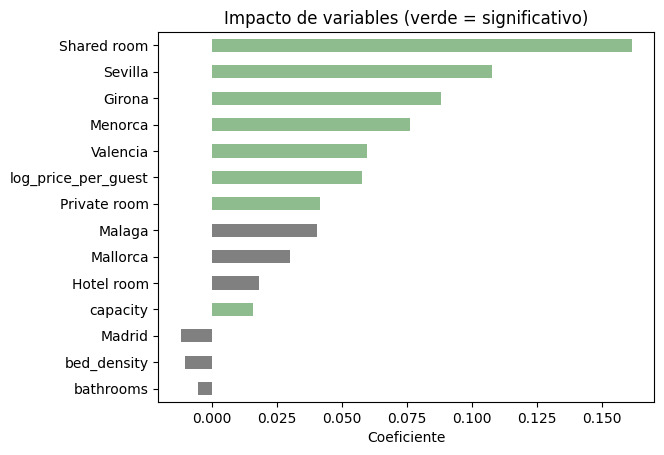

In [ ]:
coef = model.params.drop('Intercept')

summary = pd.DataFrame({
    'coef': model.params,
    'pvalue': model.pvalues
})

summary = summary.drop('Intercept')
summary['abs_coef'] = summary['coef'].abs()
summary = summary.sort_values('abs_coef')
summary.index = summary.index.str.replace('C\\(city\\)\\[T\\.', '', regex=True)
summary.index = summary.index.str.replace('C\\(room_type\\)\\[T\\.', '', regex=True)
summary.index = summary.index.str.replace('\\]', '', regex=True)

colors = ['darkseagreen' if p < 0.05 else 'grey' for p in summary['pvalue']]

summary['coef'].plot(kind='barh', color=colors)


plt.title("Impacto de variables (verde = significativo)")
plt.xlabel("Coeficiente")
plt.show()

✔️ Variables estructurales

capacity → sí influye (positivo)

price → sí influye (positivo)

bathrooms → no

bed_density → no

✔️ Variables de control (muy importantes)

ciudades → diferencias claras

tipo de alojamiento → impacto fuerte

Las variables estructurales relacionadas con el tamaño del alojamiento influyen en la disponibilidad, mientras que la configuración interna tiene un impacto limitado. Además, factores como la ciudad o el tipo de alojamiento presentan efectos más relevantes.

In [ ]:
coef = model_interaction.params.drop('Intercept')


summary = pd.DataFrame({
    'coef': model_interaction.params,
    'pvalue': model_interaction.pvalues
})

summary = summary.drop('Intercept')
summary['abs_coef'] = summary['coef'].abs()
summary = summary.sort_values('abs_coef')
summary.index = summary.index.str.replace('C\\(city\\)\\[T\\.', '', regex=True)
summary.index = summary.index.str.replace('C\\(room_type\\)\\[T\\.', '', regex=True)
summary.index = summary.index.str.replace('\\]', '', regex=True)

colors = ['darkseagreen' if p < 0.05 else 'grey' for p in summary['pvalue']]

summary['coef'].plot(kind='barh', color=colors)


plt.title("Impacto de variables (verde = significativo)")
plt.xlabel("Coeficiente")
plt.show()

#### Info extra

In [ ]:
sns.boxplot(
    x='bathrooms',
    y='availability_30_pct',
    data=df_model
)

In [ ]:
sns.scatterplot(
    x='bed_density',
    y='availability_30_pct',
    data=df_model,
    alpha=0.3
)

#### Conclusiones generales

La disponibilidad de los alojamientos muestra una distribución polarizada, 
con una parte importante de listings altamente ocupados y otros con baja ocupación.

El análisis por capacidad indica que los alojamientos más grandes tienden a 
presentar mayor disponibilidad, lo que sugiere una menor ocupación relativa.

Asimismo, se observan diferencias entre ciudades, lo que refleja una demanda 
heterogénea en función del contexto geográfico.

El modelo de regresión captura estas tendencias generales, aunque presenta una 
capacidad limitada para predecir la disponibilidad individual, lo que indica 
la existencia de factores relevantes no incluidos en el análisis.